Dataset Shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  

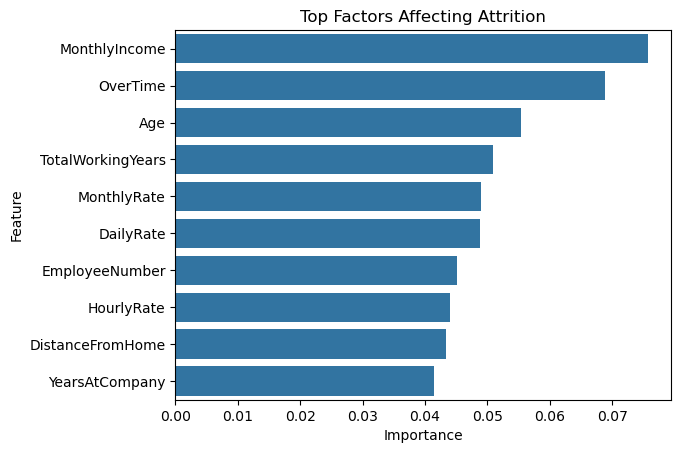


===== HR Dashboard KPIs =====
Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12%


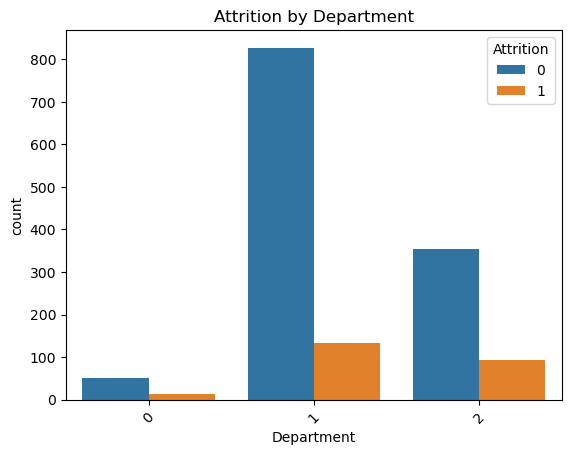

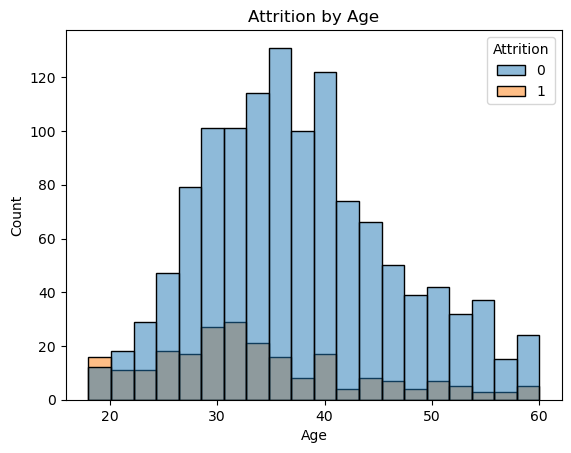

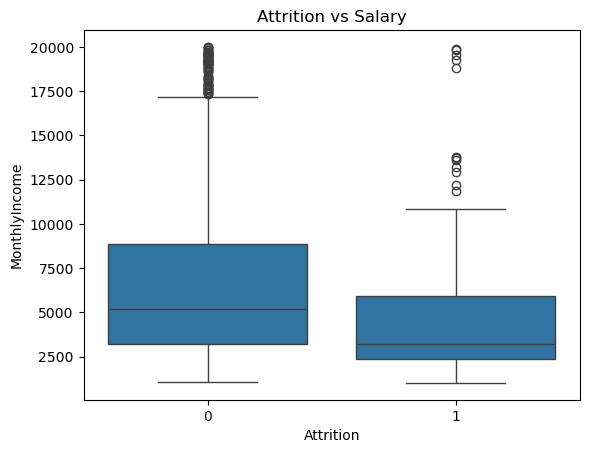

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Shape:", df.shape)
print(df.head())

df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


X = df.drop(columns=['Attrition'])
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)


rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

def evaluate(model, name):
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

evaluate(lr, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Factors Influencing Attrition:")
print(feat_df.head(10))


plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Factors Affecting Attrition")
plt.show()



total_employees = len(df)
attrition_count = df['Attrition'].sum()
attrition_rate = (attrition_count / total_employees) * 100

print("\n===== HR Dashboard KPIs =====")
print("Total Employees:", total_employees)
print("Employees Left:", attrition_count)
print("Attrition Rate: {:.2f}%".format(attrition_rate))

plt.figure()
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.histplot(data=df, x='Age', hue='Attrition', bins=20)
plt.title("Attrition by Age")
plt.show()

plt.figure()
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Salary")
plt.show()